In [25]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [26]:


nb_qubits = 6

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

# b = np.array([0]+[1]*47+[2]*5+[0]*11])

c = 1e-0
v0 = 1
y = 1
b = np.array([0,c,0,0,0,0,0,0,0,0,0,0,0,0,0,c+v0*y]*4)
b=b/np.linalg.norm(b)

In [27]:
np.linalg.det(m)



64.0000000000006

In [28]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([-4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106e-48-5.47382213e-48j,
       -1.38777878e-17+2.77555756e-17j, -9.24446373e-33-6.16297582e-33j,
       -9.71445147e-17+2.77555756e-17j,  4.47213595e-01+1.11022302e-16j,
       -4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106

In [29]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(p,q,i,j,k,l):
        return np.kron(p,np.kron(q,np.kron(i,np.kron(j,np.kron(k,l)))))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [30]:
d,u = np.linalg.eig(A)
d

array([1.19438555e+01-7.38613527e-17j, 1.02720576e+01-1.01338444e-16j,
       9.53474181e+00+3.72030325e-17j, 9.41120780e+00-2.64948304e-16j,
       9.41197035e+00-1.80457166e-16j, 7.84502294e+00+1.33030750e-16j,
       7.85230899e+00-1.09515188e-16j, 7.59827678e+00-1.08292917e-16j,
       7.36664009e+00+4.75848205e-17j, 7.32856677e+00+3.04297446e-16j,
       6.66866485e+00-6.71712204e-17j, 6.91869854e+00+3.39364575e-16j,
       5.71307232e+00+1.89922092e-16j, 5.59214491e+00+9.92908828e-17j,
       5.40275653e+00-1.13857358e-16j, 5.49187388e+00-7.49779599e-17j,
       5.15184720e+00-1.64042214e-16j, 4.99510578e+00+2.09111212e-16j,
       4.77978056e+00-1.61647946e-16j, 4.46809557e+00+5.77520109e-17j,
       3.98589495e+00+1.21835475e-16j, 3.64211313e+00-1.54516542e-17j,
       3.47181375e+00+5.04103487e-16j, 3.42929703e+00-1.81471538e-16j,
       3.28207514e+00-5.33866575e-17j, 2.99982107e+00-1.98443495e-16j,
       2.56948109e+00+3.76719087e-17j, 2.40233999e+00-3.15847538e-16j,
      

In [31]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
U9=scl.expm(2**8*2*np.pi*1j*A) 
U10=scl.expm(2**9*2*np.pi*1j*A) 
U11=scl.expm(2**10*2*np.pi*1j*A) 
U12=scl.expm(2**11*2*np.pi*1j*A)
U13=scl.expm(2**12*2*np.pi*1j*A) 
U14=scl.expm(2**13*2*np.pi*1j*A) 
U15=scl.expm(2**14*2*np.pi*1j*A)
U16=scl.expm(2**15*2*np.pi*1j*A) 


 
u1gate=UnitaryGate(U1)
u2gate=UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)
u9gate=UnitaryGate(U9)
u10gate=UnitaryGate(U10)
u11gate=UnitaryGate(U11)
u12gate=UnitaryGate(U12)
u13gate=UnitaryGate(U13)
u14gate=UnitaryGate(U14)
u15gate=UnitaryGate(U15)
u16gate=UnitaryGate(U16)




In [32]:
Id = np.identity(2**nb_qubits)
z0 = np.array([[1,0],
               [0,0]])
z1 = np.array([[0,0],
               [0,1]])

CU1 = np.kron(Id,z0) + np.kron(U1,z1)
CU2 = np.kron(Id,z0) + np.kron(U2,z1)
CU3 = np.kron(Id,z0) + np.kron(U3,z1)
CU4 = np.kron(Id,z0) + np.kron(U4,z1)
CU5 = np.kron(Id,z0) + np.kron(U5,z1)
CU6 = np.kron(Id,z0) + np.kron(U6,z1)
CU7 = np.kron(Id,z0) + np.kron(U7,z1)
CU8 = np.kron(Id,z0) + np.kron(U8,z1)
CU9 = np.kron(Id,z0) + np.kron(U9,z1)
CU10 = np.kron(Id,z0) + np.kron(U10,z1)
CU11 = np.kron(Id,z0) + np.kron(U11,z1)
CU12 = np.kron(Id,z0) + np.kron(U12,z1)
CU13 = np.kron(Id,z0) + np.kron(U13,z1)
CU14 = np.kron(Id,z0) + np.kron(U14,z1)
CU15 = np.kron(Id,z0) + np.kron(U15,z1)
CU16 = np.kron(Id,z0) + np.kron(U16,z1)


C_u1gate=UnitaryGate(CU1)
C_u2gate=UnitaryGate(CU2)
C_u3gate=UnitaryGate(CU3)
C_u4gate=UnitaryGate(CU4)
C_u5gate=UnitaryGate(CU5)
C_u6gate=UnitaryGate(CU6)
C_u7gate=UnitaryGate(CU7)
C_u8gate=UnitaryGate(CU8)
C_u9gate=UnitaryGate(CU9)
C_u10gate=UnitaryGate(CU10)
C_u11gate=UnitaryGate(CU11)
C_u12gate=UnitaryGate(CU12)
C_u13gate=UnitaryGate(CU13)
C_u14gate=UnitaryGate(CU14)
C_u15gate=UnitaryGate(CU15)
C_u16gate=UnitaryGate(CU16)


[0.16872208 0.12130657 0.43613278 0.61832446 0.84341181 0.80664178
 0.39862257 0.29943082 0.24536103 0.60196306 0.37425955 0.52972132
 0.43102362 0.38188156 0.78272281 0.72107725 0.6450553  0.09797884
 0.51106623 0.9992096  0.34266768 0.98555395 0.15913782 0.13664375
 0.20405246 0.01021576 0.02334657 0.76491246 0.62505268 0.19454975
 0.66007917 0.70608161 0.54444176 0.99423408 0.30452808 0.51740184
 0.44677501 0.59257057 0.57272667 0.51471138 0.8879971  0.83424413
 0.57718288 0.09776737 0.64540004 0.03531412 0.11936869 0.94460558
 0.12962327 0.62232019 0.27554543 0.12629759 0.08166926 0.05970105]


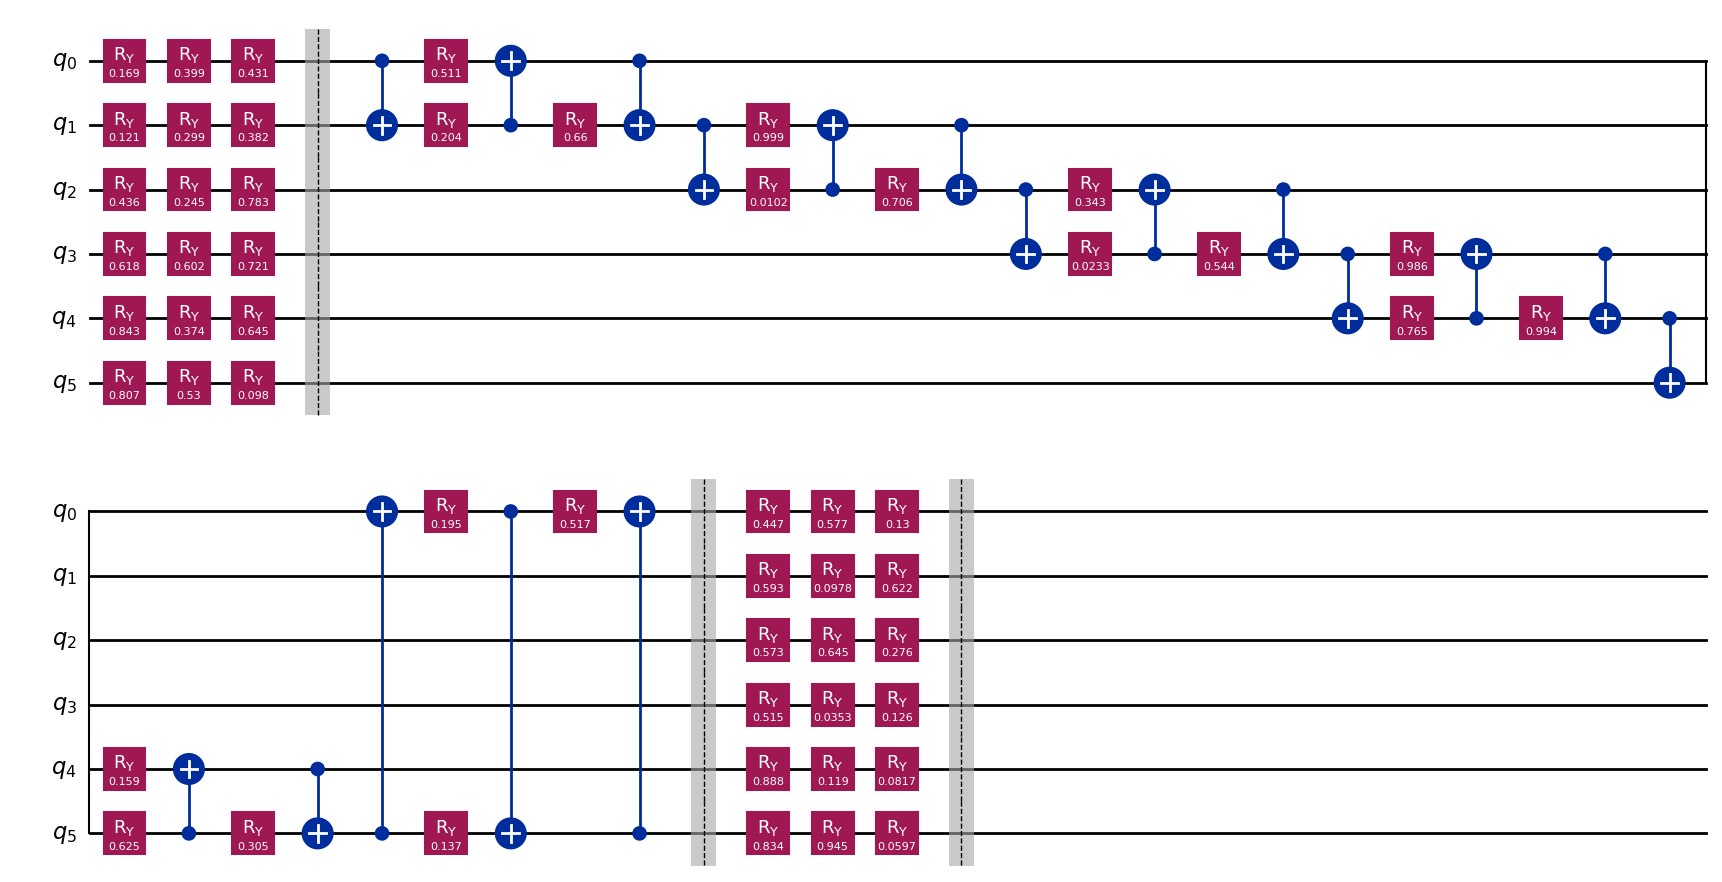

In [33]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
Parameters = np.array([random.random() for _ in range(0, nb_params)])

print(Parameters)
ansatz(Parameters).draw("mpl")

In [23]:

# def ansatz(Parameters):
#     qc = QuantumCircuit(nb_qubits)
#     for d in range(depth):
#         parameters = Parameters[d*36:(d+1)*36]
#         qc.rz(parameters[0],0)
#         qc.ry(parameters[1],0)
#         qc.rz(parameters[2],0)
    
#         qc.rz(parameters[3],1)
#         qc.ry(parameters[4],1)
#         qc.rz(parameters[5],1)
    
#         qc.rz(parameters[6],2)
#         qc.ry(parameters[7],2)
#         qc.rz(parameters[8],2)

#         qc.rz(parameters[9],3)
#         qc.ry(parameters[10],3)
#         qc.rz(parameters[11],3)
    
#         qc.cx(0,1)
#         qc.cx(2,0)
#         qc.cx(1,3)
#         qc.cx(3,2)
    
#         qc.rz(parameters[12],0)
#         qc.ry(parameters[13],0)
#         qc.rz(parameters[14],0)
    
#         qc.rz(parameters[15],1)
#         qc.ry(parameters[16],1)
#         qc.rz(parameters[17],1)

#         qc.rz(parameters[18],2)
#         qc.ry(parameters[19],2)
#         qc.rz(parameters[20],2)

#         qc.rz(parameters[21],3)
#         qc.ry(parameters[22],3)
#         qc.rz(parameters[23],3)
    
#         qc.cx(1,0)
#         qc.cx(1,2)
#         qc.cx(0,3)
#         qc.cx(3,1)
#         if d == depth - 1:
#             qc.rz(Parameters[(d+1)*36-12],0)
#             qc.ry(Parameters[(d+1)*36-11],0)
#             qc.rz(Parameters[(d+1)*36-10],0)
        
#             qc.rz(Parameters[(d+1)*36-9],1)
#             qc.ry(parameters[(d+1)*36-8],1)
#             qc.rz(Parameters[(d+1)*36-7],1)
            
#             qc.rz(Parameters[(d+1)*36-6],2)
#             qc.ry(Parameters[(d+1)*36-5],2)
#             qc.rz(Parameters[(d+1)*36-4],2)

#             qc.rz(Parameters[(d+1)*36-3],3)
#             qc.ry(Parameters[(d+1)*36-2],3)
#             qc.rz(Parameters[(d+1)*36-1],3)
#     return qc
# depth = 1
# Parameters = np.array([random.random() for _ in range(0, 72)])


# print(Parameters)
# ansatz(Parameters).draw("mpl")


In [34]:
def circ(Parameters):
    x=QuantumRegister(22)
    c=ClassicalRegister(16)
    circuit = QuantumCircuit(x,c)
    circuit=circuit.compose(ansatz(Parameters),x[16:22])
    circuit.h(x[0:16])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u2gate, [x[1],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u3gate, [x[2],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u4gate, [x[3],x[16],x[17],x[18],x[19],x[20],x[21]])  
    circuit.append(C_u5gate, [x[4],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u6gate, [x[5],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u7gate, [x[6],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u8gate, [x[7],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u9gate, [x[8],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u10gate, [x[9],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u11gate, [x[10],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u12gate, [x[11],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u13gate, [x[12],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u14gate, [x[13],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u15gate, [x[14],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u16gate, [x[15],x[16],x[17],x[18],x[19],x[20],x[21]])    
    # circuit.append(C_u17, [x[16],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    # circuit.append(C_u18, [x[17],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])
#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True, 
                   inverse = True, insert_barriers = False, name ='qftinv')
    circuit.measure(x[0:16],c)       
    return circuit

In [35]:
1/2**16

1.52587890625e-05

/tmp/ipykernel_847632/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


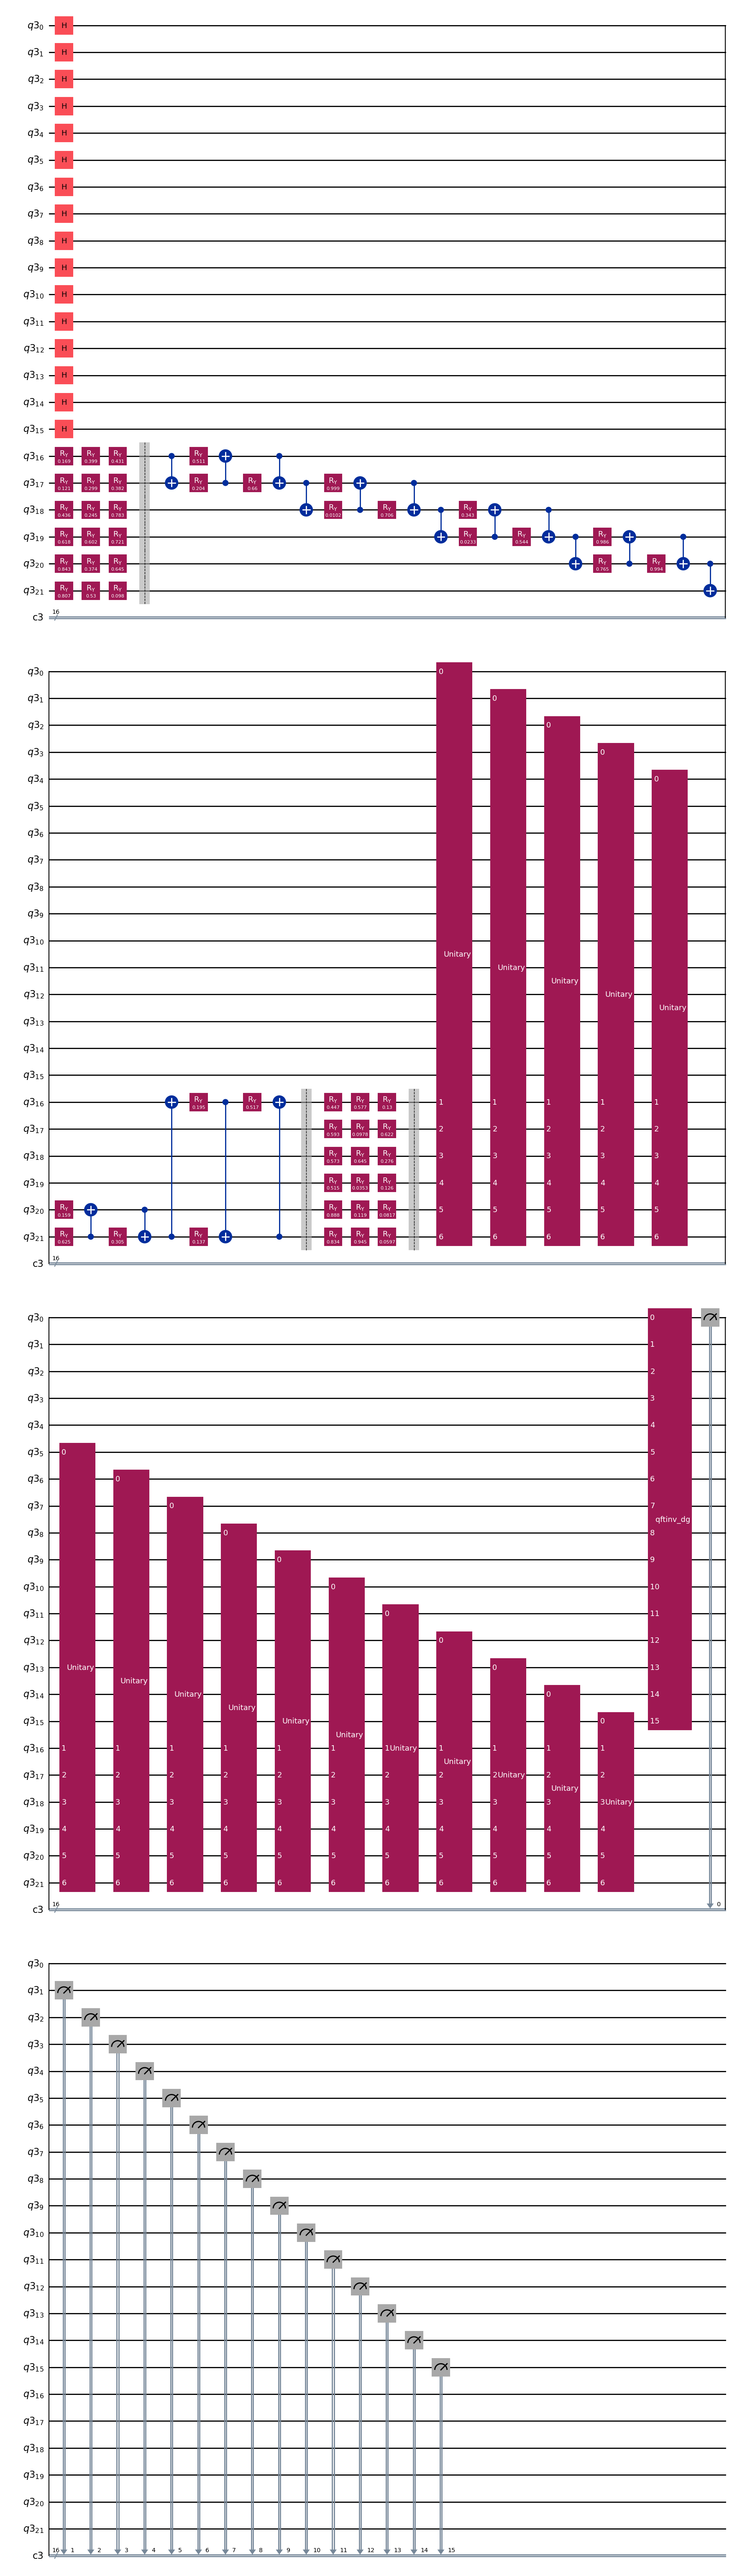

In [36]:
circ(Parameters).draw("mpl") 

In [40]:
pm=generate_preset_pass_manager(basis_gates=['cx','sx','rz','x'],optimization_level=2)
circ1=pm.run(circ(Parameters))
circ1.depth()

/tmp/ipykernel_847632/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


464805

In [14]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '0000000000000000'not in result: 
        res = 1
    else:
        res = 1 - result['0000000000000000']/shots
    return res
cost(Parameters)


/tmp/ipykernel_1194254/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


0.99419

In [15]:

def Optimizer(fun, x0, args=(), maxfev=None, 
              reset_interval=None, eps=None, callback=None, **_):
    
    x0 = np.asarray(x0)
    recycle_z0 = None
    niter = 0
    funcalls = 0

    while True:

        idx = niter % x0.size

        if reset_interval > 0:
            if niter % reset_interval == 0:
                recycle_z0 = None

        if recycle_z0 is None:
            z0 = fun(np.copy(x0), *args)
            funcalls += 1
        else:
            z0 = recycle_z0

        p = np.copy(x0)
        p[idx] = x0[idx] + np.pi / 2
        z1 = fun(p, *args)
        funcalls += 1

        p = np.copy(x0)
        p[idx] = x0[idx] - np.pi / 2
        z3 = fun(p, *args)
        funcalls += 1

        z2 = z1 + z3 - z0
        c = (z1 + z3) / 2
        a = np.sqrt((z0 - z2) ** 2 + (z1 - z3) ** 2) / 2
        b = np.arctan((z1 - z3) / ((z0 - z2) + 1e-32 * (z0 == z2))) + x0[idx]
        b += 0.5 * np.pi + 0.5 * np.pi * np.sign((z0 - z2) + eps * (z0 == z2))
        x0[idx] = b
        recycle_z0 = c - a
        if callback is not None:
            callback(np.copy(x0))
        if funcalls >= maxfev:
            break
        niter += 1
    # return OptimizeResult(fun=problabel0(np.copy(x0)), x=x0, nit=niter, 
    #                       nfev=funcalls, success=(niter > 1))

In [16]:
def save(Parameters):
    global Cost,Params
    Cost.append(cost(Parameters))
    Params.append(Parameters)
    print(cost(Parameters))
Cost = []
Params = []
Optimizer(cost, Parameters, args=(), maxfev = 6000, 
          reset_interval = 32, eps=1e-32, callback=save)
    

/tmp/ipykernel_1194254/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


0.99188
0.96862
0.96348
0.95864
0.95804
0.95413
0.95373
0.94937
0.94844
0.94548
0.94589
0.91858
0.89627
0.88655
0.88559
0.88281
0.88301
0.81272
0.81447
0.77342
0.62184
0.62342
0.62368
0.59771
0.5385
0.5301400000000001
0.52271
0.34051
0.34392
0.33003000000000005
0.32989
0.32721
0.31714
0.31137000000000004
0.30172
0.28689
0.28732
0.28295000000000003
0.2845
0.28034000000000003
0.24802999999999997
0.24531999999999998
0.24245000000000005
0.24009999999999998
0.24631999999999998
0.24409999999999998
0.24228000000000005
0.24392000000000003
0.24209000000000003
0.24067000000000005
0.24068
0.24029
0.23912999999999995
0.24373999999999996
0.2388
0.23619
0.23321999999999998
0.23407
0.23129999999999995
0.23243999999999998
0.23204999999999998
0.22985
0.23172000000000004
0.23362000000000005
0.22931999999999997
0.23165000000000002
0.23053999999999997
0.23358
0.23211000000000004
0.23292999999999997
0.23165999999999998
0.23446
0.22953
0.22491000000000005
0.22707
0.22585999999999995
0.22274000000000005
0.20

KeyboardInterrupt: 

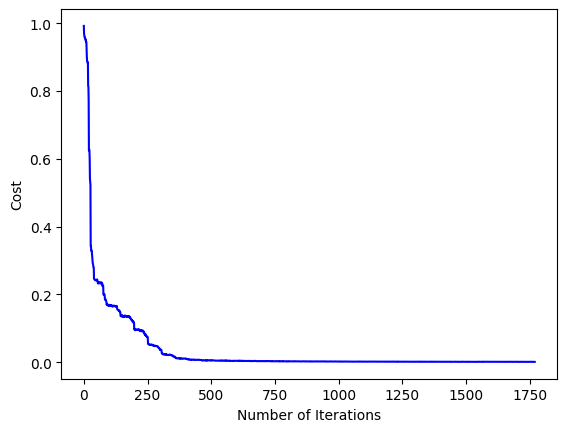

In [17]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [18]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [19]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

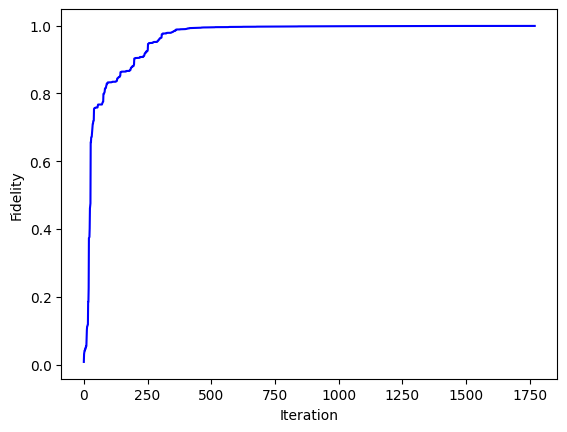

In [20]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [21]:
norm_e[np.argmax(F)]

31.52667491559396

In [22]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.00898911, 0.39019881, 0.52973836, 0.92814957, 1.12244091,
       1.42957862, 1.6381278 , 1.94710706, 2.25444874, 2.42930021,
       2.74125232, 2.90427644, 3.25997873, 3.29886339, 3.68872895,
       3.71740435, 3.87928659, 4.16528573, 4.23137019, 4.51309421,
       4.58784311, 4.74557979, 4.85751174, 5.00790842, 5.1103881 ,
       5.21565393, 5.29573934, 5.37610037, 5.4592797 , 5.40664218,
       5.54947476, 5.46671992, 5.56130024, 5.55634487, 5.54485533,
       5.49502397, 5.40867331, 5.3930772 , 5.28683841, 5.23783846,
       5.13983869, 4.96581502, 4.91432874, 4.7209651 , 4.59534857,
       4.42257739, 4.2796762 , 4.10187702, 3.96654667, 3.88309419,
       3.58078689, 3.46742223, 3.13614795, 2.99087141, 2.68473114,
       2.52498383, 2.22953943, 1.90188573, 1.72982056, 1.39440064,
       1.21807659, 0.83069317, 0.68986208, 0.31124152])

In [24]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [25]:
abs(np.array(e[-1]))

array([0.00898911, 0.39019881, 0.52973836, 0.92814957, 1.12244091,
       1.42957862, 1.6381278 , 1.94710706, 2.25444874, 2.42930021,
       2.74125232, 2.90427644, 3.25997873, 3.29886339, 3.68872895,
       3.71740435, 3.87928659, 4.16528573, 4.23137019, 4.51309421,
       4.58784311, 4.74557979, 4.85751174, 5.00790842, 5.1103881 ,
       5.21565393, 5.29573934, 5.37610037, 5.4592797 , 5.40664218,
       5.54947476, 5.46671992, 5.56130024, 5.55634487, 5.54485533,
       5.49502397, 5.40867331, 5.3930772 , 5.28683841, 5.23783846,
       5.13983869, 4.96581502, 4.91432874, 4.7209651 , 4.59534857,
       4.42257739, 4.2796762 , 4.10187702, 3.96654667, 3.88309419,
       3.58078689, 3.46742223, 3.13614795, 2.99087141, 2.68473114,
       2.52498383, 2.22953943, 1.90188573, 1.72982056, 1.39440064,
       1.21807659, 0.83069317, 0.68986208, 0.31124152])

In [26]:
X_opt

array([-0.00029446+0.j,  0.01244579+0.j,  0.016741  +0.j,  0.02951626+0.j,
        0.03560502+0.j,  0.04539037+0.j,  0.05194618+0.j,  0.06179185+0.j,
        0.07158388+0.j,  0.07703582+0.j,  0.08697888+0.j,  0.09204339+0.j,
        0.1034196 +0.j,  0.10441759+0.j,  0.11691291+0.j,  0.11757646+0.j,
        0.12272446+0.j,  0.13193825+0.j,  0.13400858+0.j,  0.14314277+0.j,
        0.14549693+0.j,  0.15056958+0.j,  0.15414177+0.j,  0.15897397+0.j,
        0.16223653+0.j,  0.16559035+0.j,  0.16811932+0.j,  0.17065732+0.j,
        0.17328763+0.j,  0.1714689 +0.j,  0.17605332+0.j,  0.17324801+0.j,
        0.1763727 +0.j,  0.17623682+0.j,  0.17594734+0.j,  0.17440187+0.j,
        0.17166011+0.j,  0.17123611+0.j,  0.16784286+0.j,  0.16632462+0.j,
        0.16320126+0.j,  0.15758753+0.j,  0.15598785+0.j,  0.14974059+0.j,
        0.14571257+0.j,  0.14013987+0.j,  0.13554564+0.j,  0.12980824+0.j,
        0.12558291+0.j,  0.12305698+0.j,  0.11342231+0.j,  0.10997697+0.j,
        0.09939341+0.j,  

In [27]:
print(F)

[0.007976424701121289, 0.031340522630852914, 0.03646966344174718, 0.04170536347677537, 0.041714647441638476, 0.045141281184547244, 0.045147367903076455, 0.05068344953025841, 0.0507030614476061, 0.05458674576523354, 0.05460195548751759, 0.08130469624712239, 0.10285472044708427, 0.11265826635131389, 0.11368963098317626, 0.11688153140957792, 0.11761301654290479, 0.185248273471151, 0.1854068380418401, 0.22606864962163895, 0.3733486474055453, 0.3753459965072617, 0.37653505881716, 0.401935612940908, 0.46059757965004977, 0.467264955424719, 0.475830991247024, 0.6561526816771812, 0.656226623886641, 0.6705532584375856, 0.6710128275626263, 0.6718443664814937, 0.6811180058229884, 0.6889051637250018, 0.6983474115875551, 0.7102119788484941, 0.7106741714176424, 0.7176298739758894, 0.7191042931535515, 0.7194655101958733, 0.7540455830624656, 0.755852452766677, 0.7568766152384923, 0.7569203049623626, 0.7569234816468454, 0.7572276771257574, 0.7581863274454094, 0.758201534983892, 0.7582248323505476, 0.758

In [28]:
print(norm_e)

[3.6032136354176783, 7.1994772137133936, 7.475351504833526, 7.990017375935369, 7.98563223662529, 12.51511196800841, 12.525234042096699, 8.35164458013789, 8.27570542050303, 9.525854089070362, 9.644085120645373, 19.844874588278536, 10.907538571828711, 9.776081899127377, 9.652394609171587, 10.14649581936571, 9.56842258696594, 3.9698398066464153, 4.0750352891684045, 8.302060876592996, 4.650254146656254, 5.55119707484145, 6.647081071049624, 9.663083686053117, 3.9435091014674284, 3.8698413963246088, 4.430969695697532, 8.284062498531462, 8.07711353875868, 10.761795603388018, 12.44559332296825, 10.789089368841807, 5.464197936998463, 4.5860442957578496, 6.336882639290923, 25.23767965775582, 15.236724625536379, 18.4217157657685, 16.239433110434156, 17.58252260942684, 62.922845768201974, 31.085783673000535, 13.885995008670761, 14.134065440196117, 14.198499664899462, 15.151092666601368, 17.0376754578203, 17.57254049718591, 15.939931454571866, 16.042746782180917, 16.10717888838429, 16.5493344299770

In [29]:
min(norm_e)

3.6032136354176783

In [30]:
1-max(F)

0.0009623713341183615